# Analyse DeepMD training curves

This notebook discovers DeepMD model files and loads the corresponding training curves by filename.
Supported examples include `graph.pb`, `model.pb`, `graph.001.pb`, `model.001.pb`, `graph_001.pb`, and `model_001.pb`.


In [32]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [33]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "model_analysis" else Path.cwd().resolve()

MODEL_DIR = PROJECT_ROOT / "model_analysis" / "model"
MODEL_PATTERN = "**/*.pb"
LCURVE_DIR = PROJECT_ROOT / "model_analysis" / "input"
LCURVE_PREFIX = "lcurve"
MODEL_PREFIXES = ["graph", "model"]
SUMMARY_WINDOW = 1000


In [34]:
import re

model_files = sorted(MODEL_DIR.glob(MODEL_PATTERN))
if not model_files:
    raise FileNotFoundError(f"No model file matched '{MODEL_PATTERN}' in {MODEL_DIR}")

MODEL_NAME_RE = re.compile(
    rf"^(?P<prefix>{'|'.join(MODEL_PREFIXES)})(?P<suffix>(?:[._].+)?)$"
)

def suffix_from_model(path: Path) -> str | None:
    stem = path.stem
    match = MODEL_NAME_RE.fullmatch(stem)
    if match is None:
        return None

    suffix = match.group("suffix")
    return suffix if suffix else ""

def lcurve_path_from_model(path: Path) -> Path | None:
    suffix = suffix_from_model(path)
    if suffix is None:
        return None
    return LCURVE_DIR / f"{LCURVE_PREFIX}{suffix}.out"

def curve_label(path: Path) -> str:
    return path.stem

curve_data = {}
missing_lcurves = []
skipped_models = []

for model_path in model_files:
    lcurve_path = lcurve_path_from_model(model_path)
    if lcurve_path is None:
        skipped_models.append(model_path)
        continue
    if not lcurve_path.exists():
        missing_lcurves.append((model_path, lcurve_path))
        continue

    data = np.genfromtxt(lcurve_path, comments="#", dtype=float)
    if data.ndim == 1:
        data = data[None, :]
    if data.shape[1] < 8:
        raise ValueError(f"Unexpected lcurve format in {lcurve_path}: expected at least 8 columns.")

    label = curve_label(model_path)
    curve_data[label] = {
        "model_path": model_path,
        "path": lcurve_path,
        "step": data[:, 0],
        "rmse_val": data[:, 1],
        "rmse_trn": data[:, 2],
        "rmse_e_val": data[:, 3],
        "rmse_e_trn": data[:, 4],
        "rmse_f_val": data[:, 5],
        "rmse_f_trn": data[:, 6],
        "learning_rate": data[:, 7],
    }
    print(f"Loaded {label}: {lcurve_path.name} for {model_path.name}")

if skipped_models:
    print("Skipped model files with unsupported names:")
    for model_path in skipped_models:
        print(f"- {model_path.name}")

if missing_lcurves:
    print("Missing matching lcurve files:")
    for model_path, lcurve_path in missing_lcurves:
        print(f"- {model_path.name} -> expected {lcurve_path.name}")

if not curve_data:
    raise FileNotFoundError(
        "No model had a matching lcurve file. Expected names like lcurve.out, lcurve.001.out, or lcurve_001.out."
    )


Loaded graph.001: lcurve.001.out for graph.001.pb
Loaded graph.002: lcurve.002.out for graph.002.pb
Loaded graph.003: lcurve.003.out for graph.003.pb
Loaded graph.004: lcurve.004.out for graph.004.pb


## Cross-model final summary


In [35]:
summary_rows = []
for label, values in curve_data.items():
    n_points = min(SUMMARY_WINDOW, len(values["step"]))
    summary_rows.append({"model": label, "n_steps": len(values["step"]), "final_learning_rate": values["learning_rate"][-1], "energy_rmse_train_last_window": values["rmse_e_trn"][-n_points:].mean(), "energy_rmse_val_last_window": values["rmse_e_val"][-n_points:].mean(), "force_rmse_train_last_window": values["rmse_f_trn"][-n_points:].mean(), "force_rmse_val_last_window": values["rmse_f_val"][-n_points:].mean()})
summary_df = pd.DataFrame(summary_rows).sort_values("force_rmse_val_last_window").reset_index(drop=True)
summary_df


,model,n_steps,final_learning_rate,energy_rmse_train_last_window,energy_rmse_val_last_window,force_rmse_train_last_window,force_rmse_val_last_window
0,graph.004,5001,3.500000e-08,0.000218,0.000217,0.021266,0.021166
1,graph.003,5001,3.500000e-08,0.000213,0.000218,0.022059,0.021901
2,graph.002,5001,3.500000e-08,0.000216,0.000215,0.022348,0.022203
3,graph.001,5001,3.500000e-08,0.000251,0.000251,0.023817,0.023637


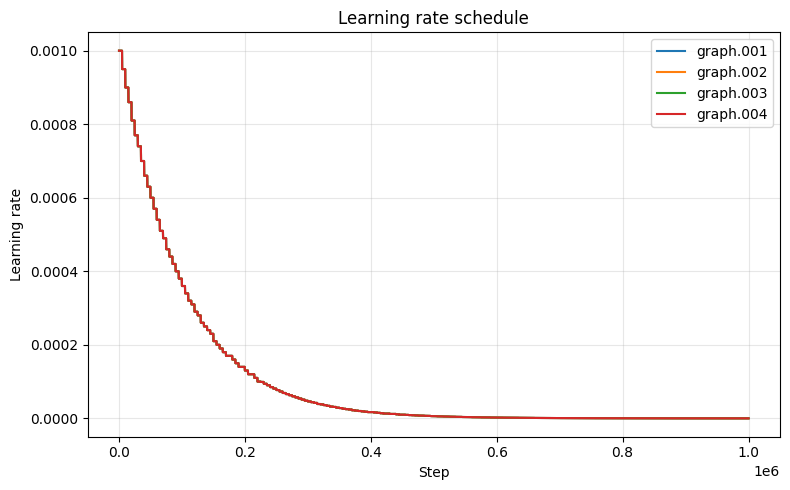

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))
for label, values in curve_data.items():
    ax.plot(values["step"], values["learning_rate"], label=label)
ax.set_xlabel("Step")
ax.set_ylabel("Learning rate")
ax.set_title("Learning rate schedule")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()


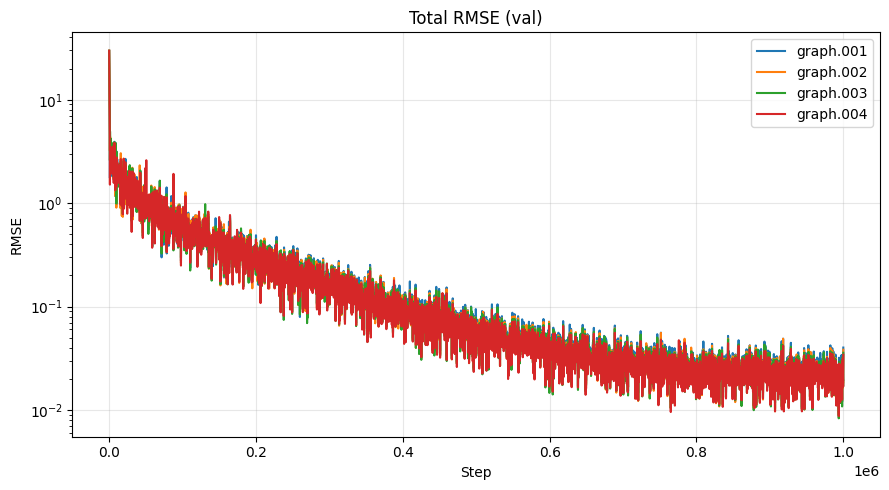

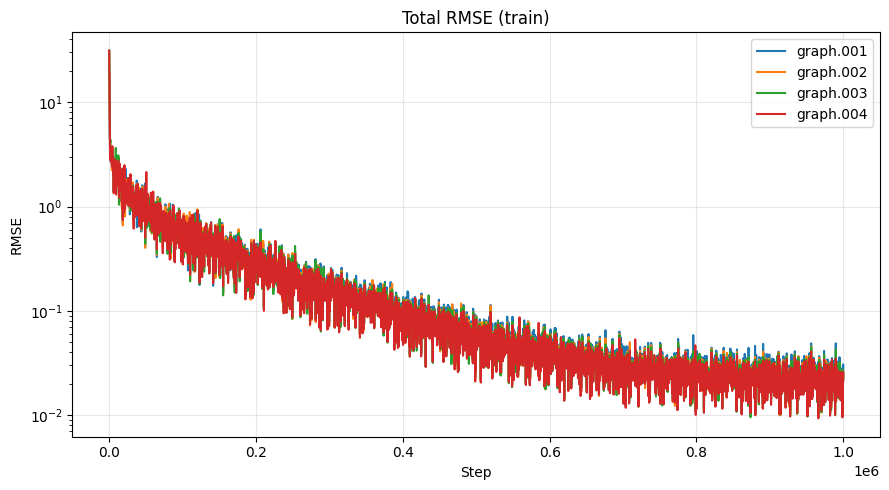

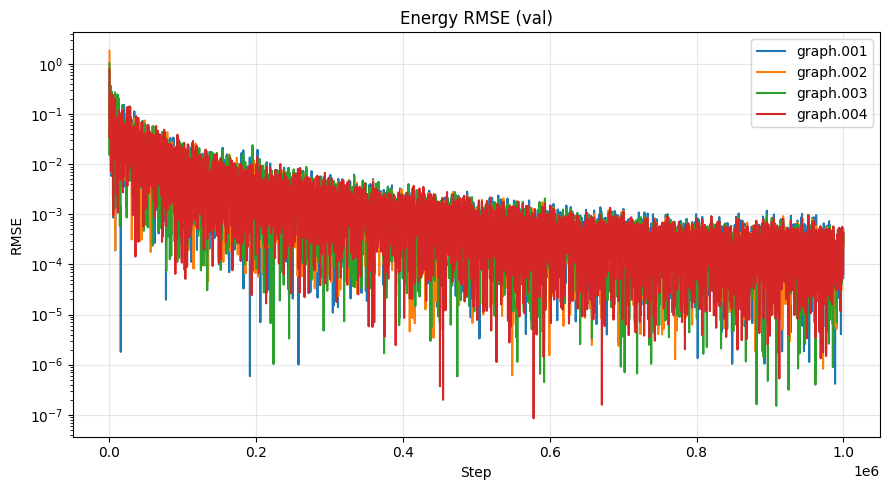

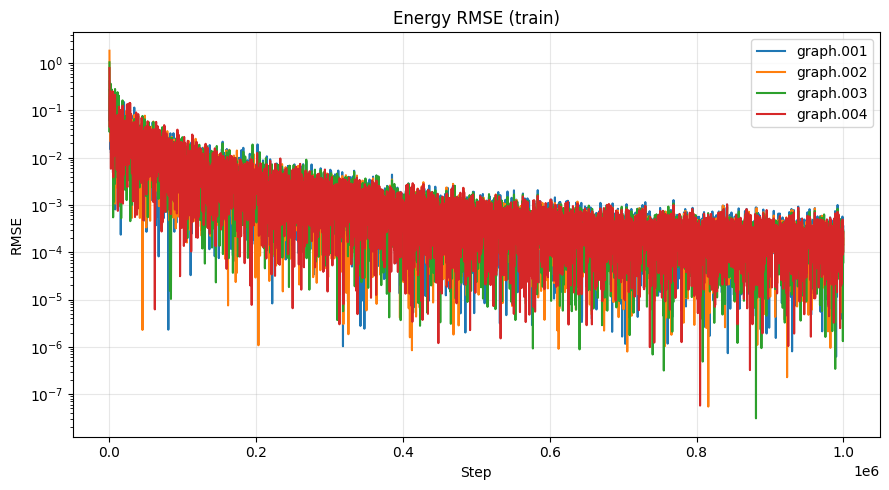

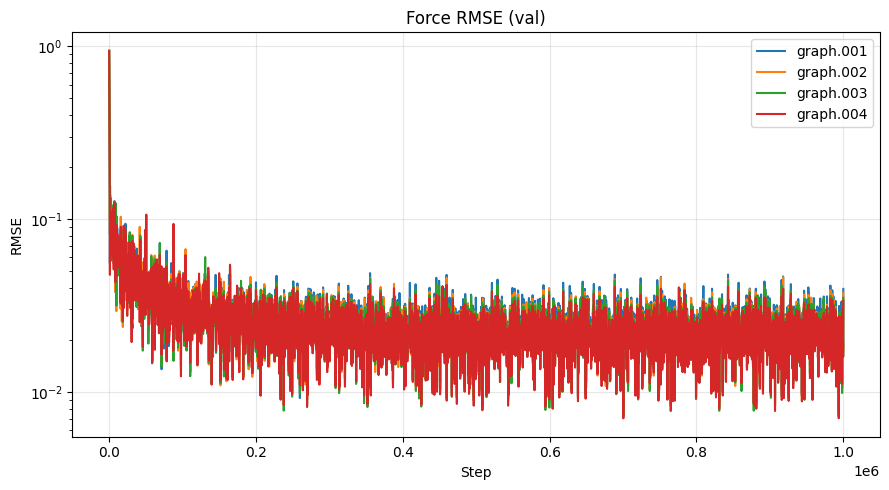

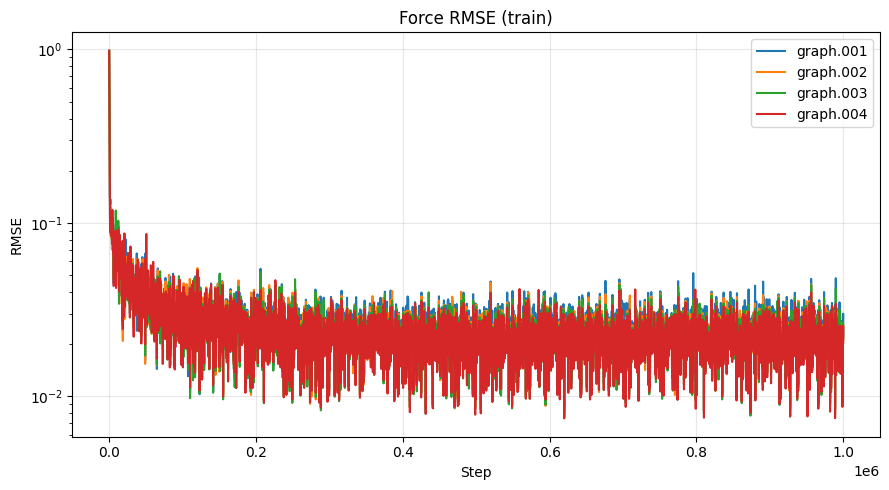

In [37]:
metrics = [("rmse_val", "Total RMSE (val)"), ("rmse_trn", "Total RMSE (train)"), ("rmse_e_val", "Energy RMSE (val)"), ("rmse_e_trn", "Energy RMSE (train)"), ("rmse_f_val", "Force RMSE (val)"), ("rmse_f_trn", "Force RMSE (train)")]

for key, title in metrics:
    fig, ax = plt.subplots(figsize=(9, 5))
    for label, values in curve_data.items():
        ax.plot(values["step"], values[key], label=label)
    ax.set_xlabel("Step")
    ax.set_ylabel("RMSE")
    ax.set_yscale("log")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.show()


Best validation energy RMSE over the last window: graph.002 (0.00021509)
Best validation force RMSE over the last window:  graph.004 (0.02116581)

Ranked summary by validation force RMSE:


,model,n_steps,final_learning_rate,energy_rmse_train_last_window,energy_rmse_val_last_window,force_rmse_train_last_window,force_rmse_val_last_window
0,graph.004,5001,3.500000e-08,0.000218,0.000217,0.021266,0.021166
1,graph.003,5001,3.500000e-08,0.000213,0.000218,0.022059,0.021901
2,graph.002,5001,3.500000e-08,0.000216,0.000215,0.022348,0.022203
3,graph.001,5001,3.500000e-08,0.000251,0.000251,0.023817,0.023637


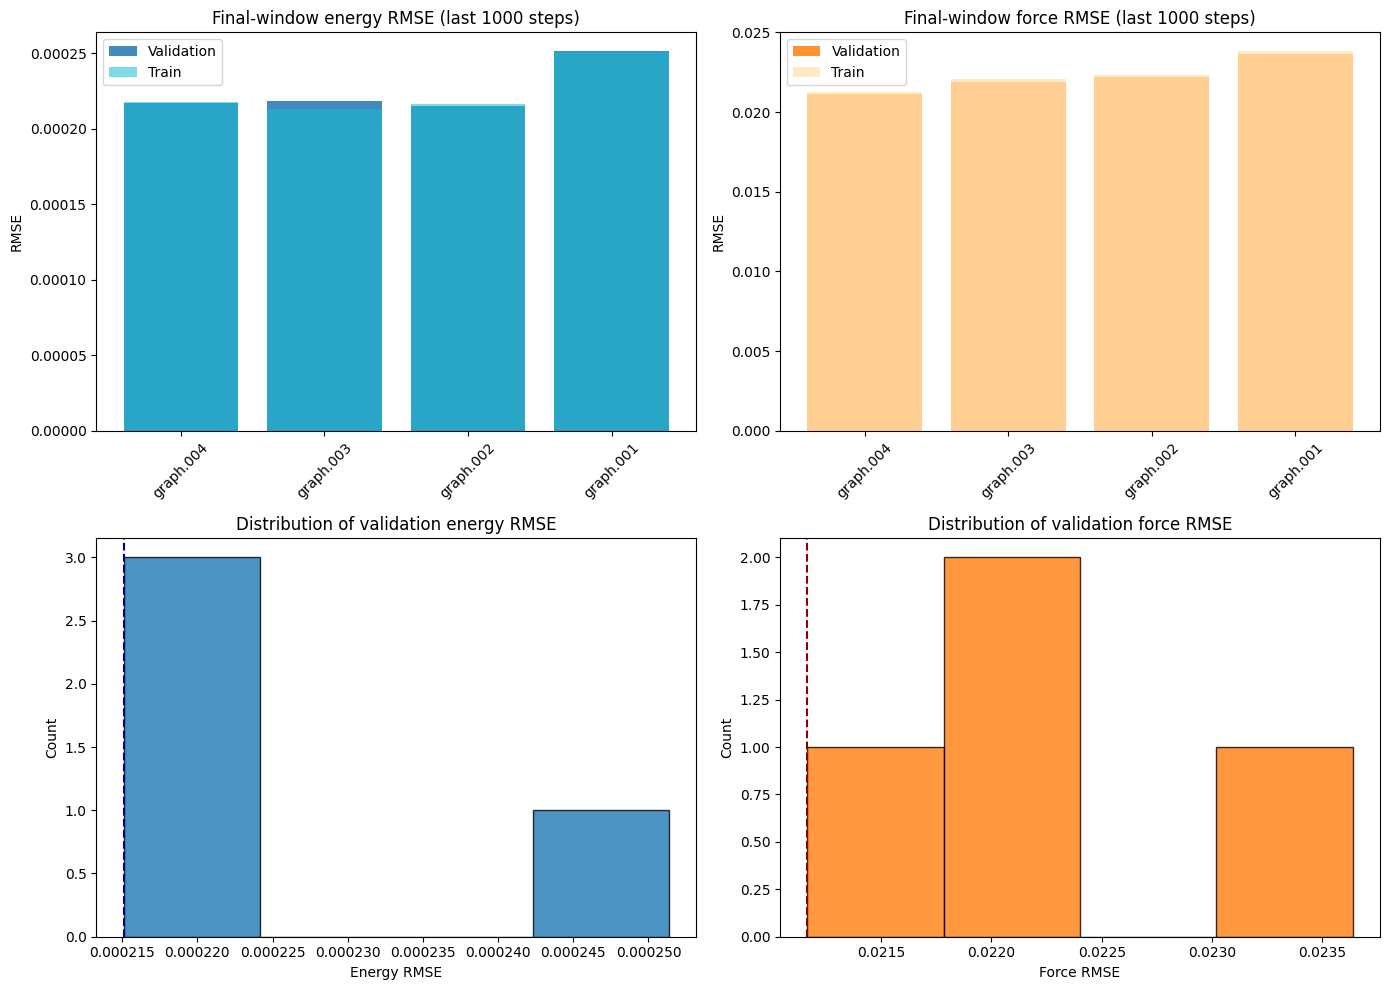

In [38]:
best_energy = summary_df.loc[summary_df["energy_rmse_val_last_window"].idxmin()]
best_force = summary_df.loc[summary_df["force_rmse_val_last_window"].idxmin()]

print(
    f"Best validation energy RMSE over the last window: {best_energy['model']} "
    f"({best_energy['energy_rmse_val_last_window']:.8f})"
)
print(
    f"Best validation force RMSE over the last window:  {best_force['model']} "
    f"({best_force['force_rmse_val_last_window']:.8f})"
)

print()
print("Ranked summary by validation force RMSE:")
display(
    summary_df.sort_values("force_rmse_val_last_window").reset_index(drop=True)
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].bar(
    summary_df["model"],
    summary_df["energy_rmse_val_last_window"],
    color="tab:blue",
    alpha=0.85,
    label="Validation",
)
axes[0, 0].bar(
    summary_df["model"],
    summary_df["energy_rmse_train_last_window"],
    color="tab:cyan",
    alpha=0.55,
    label="Train",
)
axes[0, 0].set_title(f"Final-window energy RMSE (last {SUMMARY_WINDOW} steps)")
axes[0, 0].set_ylabel("RMSE")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].legend()

axes[0, 1].bar(
    summary_df["model"],
    summary_df["force_rmse_val_last_window"],
    color="tab:orange",
    alpha=0.85,
    label="Validation",
)
axes[0, 1].bar(
    summary_df["model"],
    summary_df["force_rmse_train_last_window"],
    color="moccasin",
    alpha=0.75,
    label="Train",
)
axes[0, 1].set_title(f"Final-window force RMSE (last {SUMMARY_WINDOW} steps)")
axes[0, 1].set_ylabel("RMSE")
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].legend()

axes[1, 0].hist(
    summary_df["energy_rmse_val_last_window"],
    bins=min(10, max(3, len(summary_df))),
    color="tab:blue",
    alpha=0.8,
    edgecolor="black",
)
axes[1, 0].axvline(best_energy["energy_rmse_val_last_window"], color="darkblue", linestyle="--", linewidth=1.5)
axes[1, 0].set_title("Distribution of validation energy RMSE")
axes[1, 0].set_xlabel("Energy RMSE")
axes[1, 0].set_ylabel("Count")

axes[1, 1].hist(
    summary_df["force_rmse_val_last_window"],
    bins=min(10, max(3, len(summary_df))),
    color="tab:orange",
    alpha=0.8,
    edgecolor="black",
)
axes[1, 1].axvline(best_force["force_rmse_val_last_window"], color="darkred", linestyle="--", linewidth=1.5)
axes[1, 1].set_title("Distribution of validation force RMSE")
axes[1, 1].set_xlabel("Force RMSE")
axes[1, 1].set_ylabel("Count")

fig.tight_layout()
plt.show()
